In [14]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('train (1).csv',usecols=['Age','Fare','Survived'])
df.sample(10)


,Survived,Age,Fare
359,1,NaN,7.8792
397,0,46.0,26.0000
411,0,NaN,6.8583
207,1,26.0,18.7875
739,0,NaN,7.8958
21,1,34.0,13.0000
55,1,NaN,35.5000
725,0,20.0,8.6625
783,0,NaN,23.4500
646,0,19.0,7.8958


In [16]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [17]:
x=df.drop(columns=['Survived'])
y=df['Survived']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
x_train

,Age,Fare
140,NaN,15.2458
439,31.0,10.5000
817,31.0,37.0042
378,20.0,4.0125
491,21.0,7.2500
...,...,...
835,39.0,83.1583
192,19.0,7.8542
629,NaN,7.7333
559,36.0,17.4000


In [18]:
x_train['age_imputed']=x_train['Age']
x_test['age_imputed']=x_train['Age']

x_train.tail()

,Age,Fare,age_imputed
835,39.0,83.1583,39.0
192,19.0,7.8542,19.0
629,NaN,7.7333,NaN
559,36.0,17.4000,36.0
684,60.0,39.0000,60.0


In [23]:
n_train = x_train['age_imputed'].isna().sum()
x_train.loc[x_train['age_imputed'].isna(), 'age_imputed'] = (
    x_train['Age'].dropna().sample(n_train, replace=True).values
)

n_test = x_test['age_imputed'].isna().sum()
x_test.loc[x_test['age_imputed'].isna(), 'age_imputed'] = (
    x_test['Age'].dropna().sample(n_test, replace=True).values
)

In [24]:
x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values

array([20.  , 74.  , 29.  ,  1.  , 40.5 , 22.  ,  3.  , 48.  , 19.  ,
       22.  , 35.  , 41.  , 45.  , 28.  , 58.  , 42.  , 21.  , 36.  ,
       35.  ,  2.  , 20.  , 21.  , 40.  , 38.  , 42.  , 23.  , 54.  ,
       40.  , 25.  , 18.  , 16.  , 13.  , 32.  , 29.  , 17.  , 41.  ,
       36.  , 36.  , 23.  , 16.  , 35.  , 26.  , 34.  ,  0.75, 19.  ,
       33.  , 36.  , 47.  , 18.  , 27.  , 36.  , 30.  ,  9.  , 34.  ,
       32.  , 18.  , 27.  , 35.  , 32.  , 21.  , 31.  , 32.  , 51.  ,
       20.5 , 36.  , 34.  , 24.  , 54.  ,  0.92, 20.  , 27.  , 21.  ,
       14.  , 52.  , 70.5 ,  1.  , 16.  , 31.  , 21.  , 33.  , 16.  ,
       56.  , 29.  , 30.  , 30.  , 21.  , 44.  , 24.  , 36.  , 11.  ,
       32.  ,  1.  ,  3.  , 26.  , 32.  , 17.  , 28.  , 30.  , 11.  ,
        1.  ,  4.  , 37.  , 15.  , 33.  , 30.  , 17.  , 23.  , 48.  ,
        4.  , 19.  , 39.  , 49.  , 39.  , 17.  , 41.  ,  4.  , 20.  ,
       26.  ,  9.  , 22.  ,  2.  ,  6.  , 36.  , 30.  ,  2.  , 28.  ,
       28.5 , 22.  ,

In [25]:
x_train['Age'].isnull().sum()

np.int64(141)

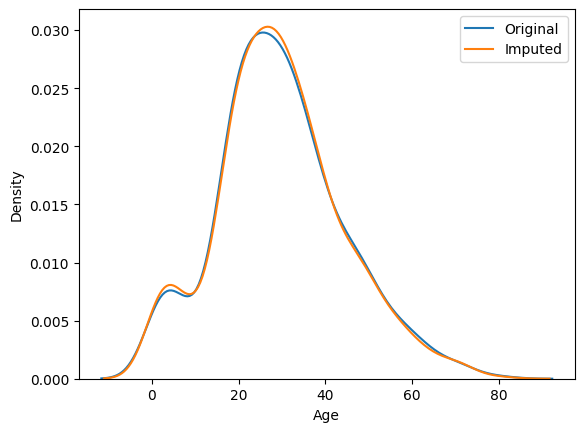

In [28]:
sns.kdeplot(x_train['Age'],label='Original')
sns.kdeplot(x_train['age_imputed'],label = 'Imputed',)

plt.legend()
plt.show()

In [29]:
print('Original variable variance: ', x_train['Age'].var())
print('Variance after random imputation: ', x_train['age_imputed'].var())

Original variable variance:  213.7165085187575
Variance after random imputation:  210.81333087418415


<Axes: >

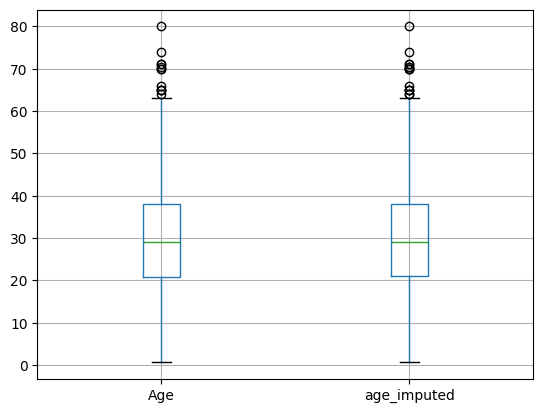

In [30]:
x_train[['Age', 'age_imputed']].boxplot()

In [31]:
data=pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [32]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [33]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [34]:
X = data
y = data['SalePrice']

In [35]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [36]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [37]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
382,NaN,TA,213500,TA,NaN
996,NaN,TA,136500,TA,NaN
1416,NaN,TA,122500,TA,NaN
1040,TA,TA,155000,TA,TA
602,TA,TA,220000,TA,TA


In [38]:
# GarageQual
n = X_train['GarageQual_imputed'].isna().sum()
X_train.loc[X_train['GarageQual_imputed'].isna(), 'GarageQual_imputed'] = (
    X_train['GarageQual'].dropna().sample(n, replace=True).values
)

n = X_test['GarageQual_imputed'].isna().sum()
X_test.loc[X_test['GarageQual_imputed'].isna(), 'GarageQual_imputed'] = (
    X_train['GarageQual'].dropna().sample(n, replace=True).values
)

# FireplaceQu
n = X_train['FireplaceQu_imputed'].isna().sum()
X_train.loc[X_train['FireplaceQu_imputed'].isna(), 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu'].dropna().sample(n, replace=True).values
)

n = X_test['FireplaceQu_imputed'].isna().sum()
X_test.loc[X_test['FireplaceQu_imputed'].isna(), 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu'].dropna().sample(n, replace=True).values
)

In [39]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [40]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp


,original,imputed
Gd,0.494272,0.666667
TA,0.412439,0.507295
Fa,0.040917,0.058361
Po,0.027823,0.040404
Ex,0.024550,0.038159


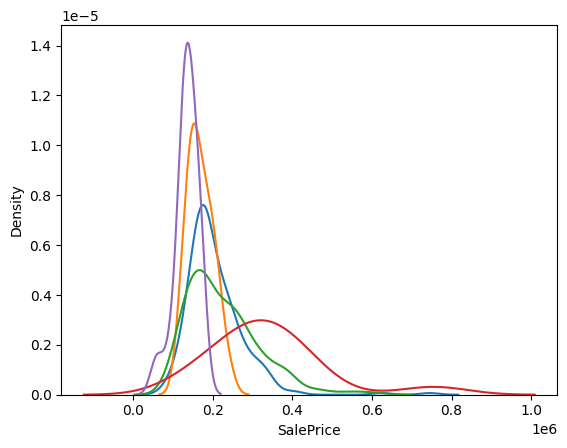

In [42]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.show()

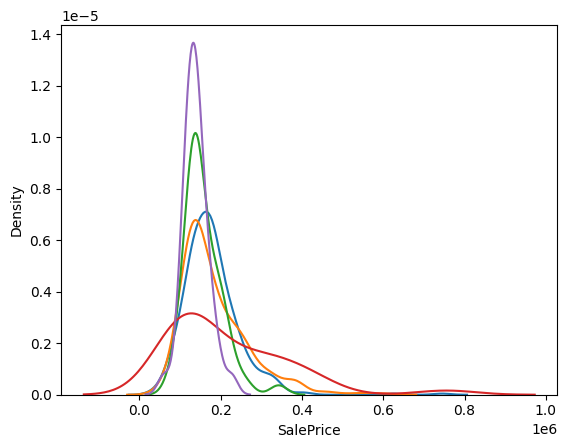

In [43]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
plt.show()